In [1]:
import numpy as np
import matplotlib.pyplot as plt
import casadi as cas

# import matplotlib.pyplot as plt
# import matplotlib
# matplotlib.use('Agg')  # needed in some Jupyter setups
# from IPython.display import display, clear_output
# import time
# import numpy as np

In [2]:
def cas_Area_fun(len):
    
    x = cas.MX.sym('x',len,1)
    y = cas.MX.sym('y',len,1)
    
    area = cas.MX.zeros(1)

    for i in range(len-1):
        area = area + (y[i]+y[i+1])*((x[i]-x[i+1]))

    fun_area = cas.Function('fun_area',[x,y],[0.5 * cas.fabs(area)])

    return fun_area


def sorting_coordinates(x,y):
    
    angles = np.arctan2(y, x)
    sort_idx = np.argsort(angles)

    x_sorted = x[sort_idx]
    y_sorted = y[sort_idx]

    return x_sorted,y_sorted


coords = np.load('Coordinates_before.npy')
x_old = coords[0]
y_old = coords[1]

# x_old,y_old = sorting_coordinates(x_old,y_old)

coords = np.load('Coordinates_after.npy')
x_new = coords[0]
y_new = coords[1]

x_new = x_new.flatten()
y_new = y_new.flatten()

# x_new,y_new = sorting_coordinates(x_new,y_new)

# fig, ax = plt.subplots()

# for i in range(N_points):
#     ax.clear()

#     # ax.plot(x_old[:i+1], y_old[:i+1], 'b-')   # accumulated path so far
#     # ax.plot(x_old[i], y_old[i], 'ro')          # current point highlighted

#     ax.plot(x_new[:i+1], y_new[:i+1], 'b-')   # accumulated path so far
#     ax.plot(x_new[i], y_new[i], 'ro')          # current point highlighted
    
#     ax.set_xlim(-1.5, 1.5)   # fix axes so plot doesn't jump around
#     ax.set_ylim(-1.5, 1.5)
#     ax.set_title(f"Iteration {i}")
#     ax.set_aspect('equal')
    
#     clear_output(wait=True)
#     display(fig)
#     time.sleep(0.05)

# plt.close()

In [ ]:
size_problem = np.size(x_old)

area_fun = cas_Area_fun(size_problem)
area_main = area_fun(x_old,y_old)

opti = cas.Opti()

x_opti = opti.variable(size_problem)
y_opti = opti.variable(size_problem)

area = opti.parameter(1,1)
current_area = opti.variable(1,1)

# J_cost = 0
# for i in range(size_problem):
#     J_cost = J_cost + (x_opti[i]-x_new[i])**2 + (y_opti[i]-y_old[i])**2 

# J_cost = cas.sumsqr(x_opti-x_old) + cas.sumsqr(y_opti-y_old)
J_cost = cas.sumsqr(x_opti-x_new) + cas.sumsqr(y_opti-y_new)

current_area = area_fun(x_opti,y_opti) 

opti.subject_to(current_area==area)

opti.set_value(area,area_main)



opti.set_initial(x_opti,x_old)
opti.set_initial(y_opti,x_old)


opti.minimize(J_cost)

opti.solver('ipopt')
sol = opti.solve()


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      300

Total number of variables............................:      300
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality c

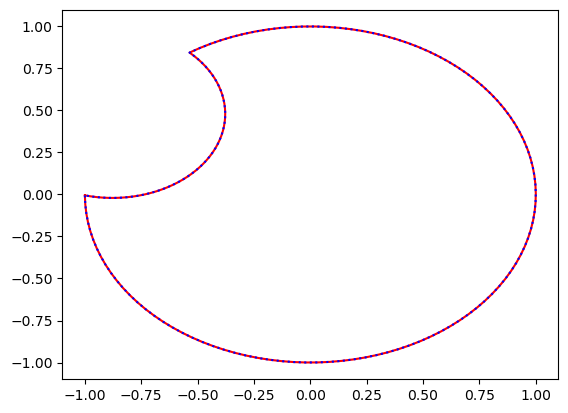

2.789738963784516


In [4]:
x = sol.value(x_opti)
y = sol.value(y_opti)

area_opt = sol.value(current_area)

plt.plot(x,y,color='red')
plt.plot(x_new,y_new,color='blue',linestyle='dotted')
# plt.plot(x_old,y_old,color='black')


plt.show()

print(area_opt)
# plt.plot(x_val,y_val,'-o')
# plt.show()